In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

# Cargar el archivo CSV
df = pd.read_csv("/content/drive/MyDrive/Alura/TelecomX/datos_tratados.csv")

# Mostrar las primeras filas para verificar
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [7]:
df = df.drop('customerID', axis=1)
display(df.head())

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [8]:
# Convertir variables categóricas a numéricas
df_encoded = pd.get_dummies(df, drop_first=True)

# Verificar resultado
df_encoded.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_Yes,...,internet_DeviceProtection_Yes,internet_TechSupport_Yes,internet_StreamingTV_Yes,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,True,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,True,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,True,False,True,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,True,False,False,False,True,False,False,True


In [9]:
df_encoded.to_csv("datos_modelo.csv", index=False)

In [12]:
df_encoded.columns

Index(['customer_SeniorCitizen', 'customer_tenure', 'account_Charges_Monthly',
       'account_Charges_Total', 'Churn_Yes', 'customer_gender_Male',
       'customer_Partner_Yes', 'customer_Dependents_Yes',
       'phone_PhoneService_Yes', 'phone_MultipleLines_Yes',
       'internet_InternetService_Fiber optic', 'internet_InternetService_No',
       'internet_OnlineSecurity_Yes', 'internet_OnlineBackup_Yes',
       'internet_DeviceProtection_Yes', 'internet_TechSupport_Yes',
       'internet_StreamingTV_Yes', 'internet_StreamingMovies_Yes',
       'account_Contract_One year', 'account_Contract_Two year',
       'account_PaperlessBilling_Yes',
       'account_PaymentMethod_Credit card (automatic)',
       'account_PaymentMethod_Electronic check',
       'account_PaymentMethod_Mailed check'],
      dtype='object')

In [13]:
df_encoded["Churn_Yes"].value_counts(normalize=True) * 100

,proportion
Churn_Yes,
False,74.280996
True,25.719004


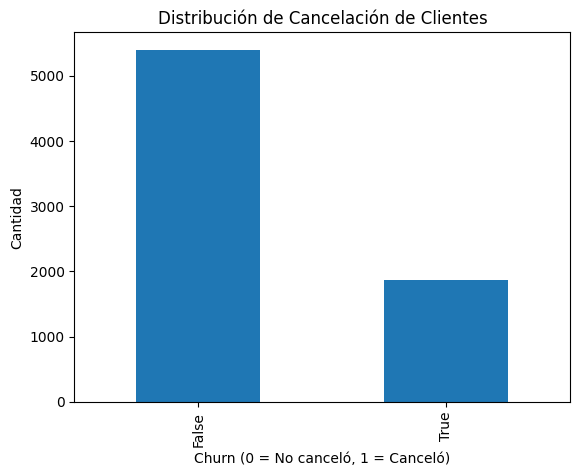

In [14]:
import matplotlib.pyplot as plt

df_encoded["Churn_Yes"].value_counts().plot(kind="bar")
plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Cantidad")
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columnas_numericas = [
    "customer_tenure",
    "account_Charges_Monthly",
    "account_Charges_Total"
]

df_encoded[columnas_numericas] = scaler.fit_transform(df_encoded[columnas_numericas])

df_encoded.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_Yes,...,internet_DeviceProtection_Yes,internet_TechSupport_Yes,internet_StreamingTV_Yes,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,-0.950200,0.029206,-0.742291,False,False,True,True,True,False,...,False,True,True,False,True,False,True,False,False,True
1,0,-0.950200,-0.159990,-0.764729,False,True,False,False,True,True,...,False,False,False,True,False,False,False,False,False,True
2,0,-1.153700,0.304702,-0.880026,True,True,False,False,True,False,...,True,False,False,False,False,False,True,False,True,False
3,1,-0.787401,1.104635,-0.458160,True,True,True,False,True,False,...,True,False,True,True,False,False,True,False,True,False
4,1,-1.194400,0.636624,-0.885955,True,False,True,False,True,False,...,False,True,True,False,False,False,True,False,False,True


In [ ]:
🎯 Correlación y Selección de Variables

In [16]:
corr_matrix = df_encoded.corr()

corr_matrix.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_Yes,...,internet_DeviceProtection_Yes,internet_TechSupport_Yes,internet_StreamingTV_Yes,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
customer_SeniorCitizen,1.000000,0.018187,0.220388,0.104076,0.146733,-0.004288,0.022970,-0.212952,0.010060,0.144567,...,0.060358,-0.059376,0.103655,0.119374,-0.046832,-0.114837,0.157734,-0.022698,0.170705,-0.154216
customer_tenure,0.018187,1.000000,0.247982,0.825407,-0.344079,0.005765,0.377551,0.159892,0.010205,0.331678,...,0.361792,0.322139,0.280738,0.286841,0.205970,0.557675,0.007949,0.235319,-0.207056,-0.234305
account_Charges_Monthly,0.220388,0.247982,1.000000,0.652211,0.189866,-0.013889,0.097122,-0.115832,0.246709,0.490699,...,0.483590,0.338429,0.628874,0.628184,0.008758,-0.077935,0.353714,0.031610,0.275550,-0.378635
account_Charges_Total,0.104076,0.825407,0.652211,1.000000,-0.193345,0.000367,0.315409,0.061474,0.113985,0.468405,...,0.523836,0.431032,0.516185,0.521490,0.175271,0.351109,0.160023,0.185229,-0.056029,-0.296090
Churn_Yes,0.146733,-0.344079,0.189866,-0.193345,1.000000,-0.009555,-0.148546,-0.161384,0.012571,0.039343,...,-0.063452,-0.160440,0.062430,0.060586,-0.173958,-0.295138,0.186666,-0.131085,0.294626,-0.090061


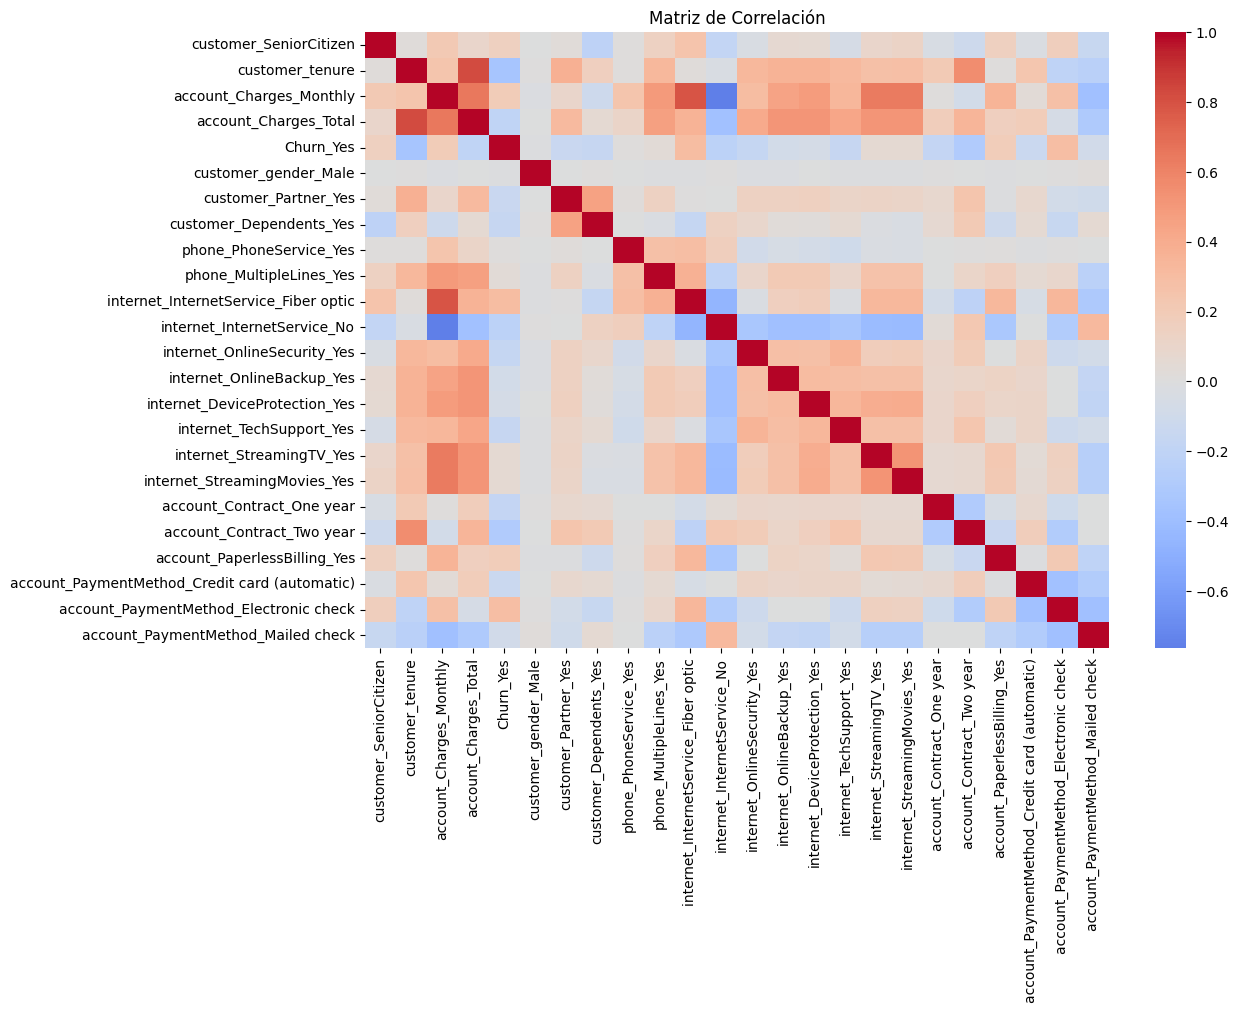

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Matriz de Correlación")
plt.show()

In [18]:
corr_churn = corr_matrix["Churn_Yes"].sort_values(ascending=False)

corr_churn

,Churn_Yes
Churn_Yes,1.000000
internet_InternetService_Fiber optic,0.300949
account_PaymentMethod_Electronic check,0.294626
account_Charges_Monthly,0.189866
account_PaperlessBilling_Yes,0.186666
customer_SeniorCitizen,0.146733
internet_StreamingTV_Yes,0.062430
internet_StreamingMovies_Yes,0.060586
phone_MultipleLines_Yes,0.039343
phone_PhoneService_Yes,0.012571


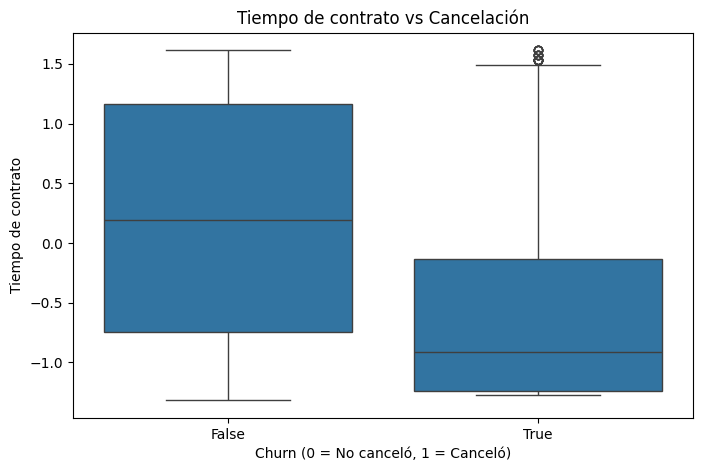

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df_encoded["Churn_Yes"], y=df_encoded["customer_tenure"])

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Tiempo de contrato")

plt.show()

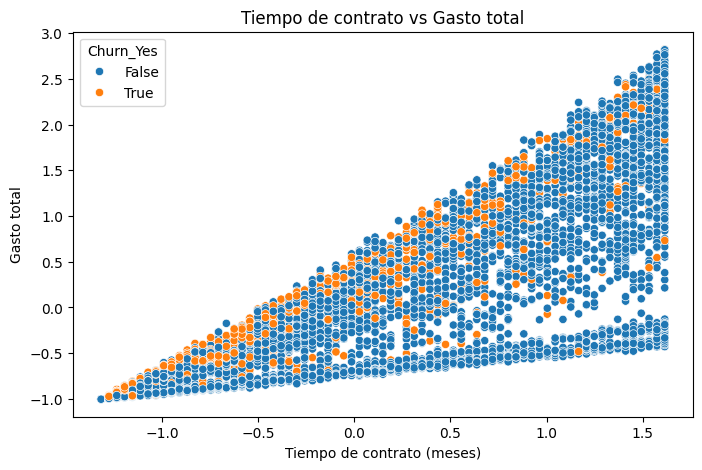

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_encoded["customer_tenure"],
    y=df_encoded["account_Charges_Total"],
    hue=df_encoded["Churn_Yes"]
)

plt.title("Tiempo de contrato vs Gasto total")
plt.xlabel("Tiempo de contrato (meses)")
plt.ylabel("Gasto total")

plt.show()

In [ ]:
🤖 Modelado Predictivo

In [23]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,   # 30% para prueba
    random_state=42
)

In [25]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5086, 23)
Prueba: (2181, 23)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
y_pred_log = modelo_logistico.predict(X_test_scaled)

In [30]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred_rf = modelo_rf.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Regresión Logística
Accuracy: 0.8005502063273727
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1620
        True       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.79      2181

Random Forest
Accuracy: 0.7835855112333792
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1620
        True       0.60      0.46      0.52       561

    accuracy                           0.78      2181
   macro avg       0.72      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [34]:
print("Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))

Regresión Logística
Accuracy: 0.8005502063273727
Precision: 0.6340425531914894
Recall: 0.5311942959001783
F1-score: 0.5780795344325897
Matriz de confusión:
[[1448  172]
 [ 263  298]]


In [35]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7835855112333792
Precision: 0.6042154566744731
Recall: 0.45989304812834225
F1-score: 0.5222672064777328
Matriz de confusión:
[[1451  169]
 [ 303  258]]


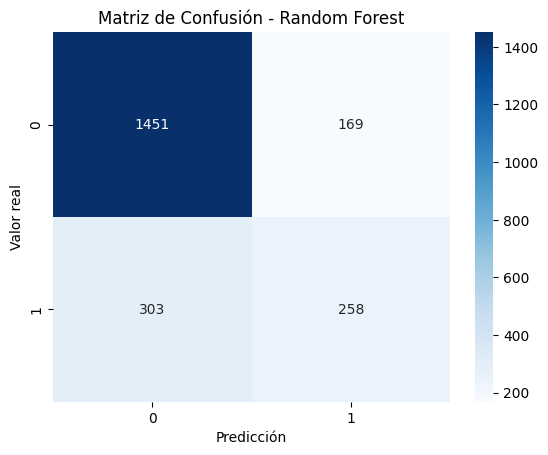

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [37]:
RandomForestClassifier(max_depth=10)

RandomForestClassifier(max_depth=10)

In [38]:
min_samples_leaf=5


##📋 Interpretación y Conclusiones

In [39]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
9,internet_InternetService_Fiber optic,0.687588
3,account_Charges_Total,0.656597
16,internet_StreamingMovies_Yes,0.239406
15,internet_StreamingTV_Yes,0.216184
8,phone_MultipleLines_Yes,0.196545
19,account_PaperlessBilling_Yes,0.190126
21,account_PaymentMethod_Electronic check,0.156075
0,customer_SeniorCitizen,0.076887
13,internet_DeviceProtection_Yes,0.064279
7,phone_PhoneService_Yes,-0.015445


In [40]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importances = importances.sort_values(by="Importancia", ascending=False)

importances.head(10)

,Variable,Importancia
3,account_Charges_Total,0.196734
2,account_Charges_Monthly,0.182236
1,customer_tenure,0.167877
9,internet_InternetService_Fiber optic,0.041888
21,account_PaymentMethod_Electronic check,0.041438
4,customer_gender_Male,0.029271
19,account_PaperlessBilling_Yes,0.028348
18,account_Contract_Two year,0.027337
5,customer_Partner_Yes,0.024235
14,internet_TechSupport_Yes,0.023277


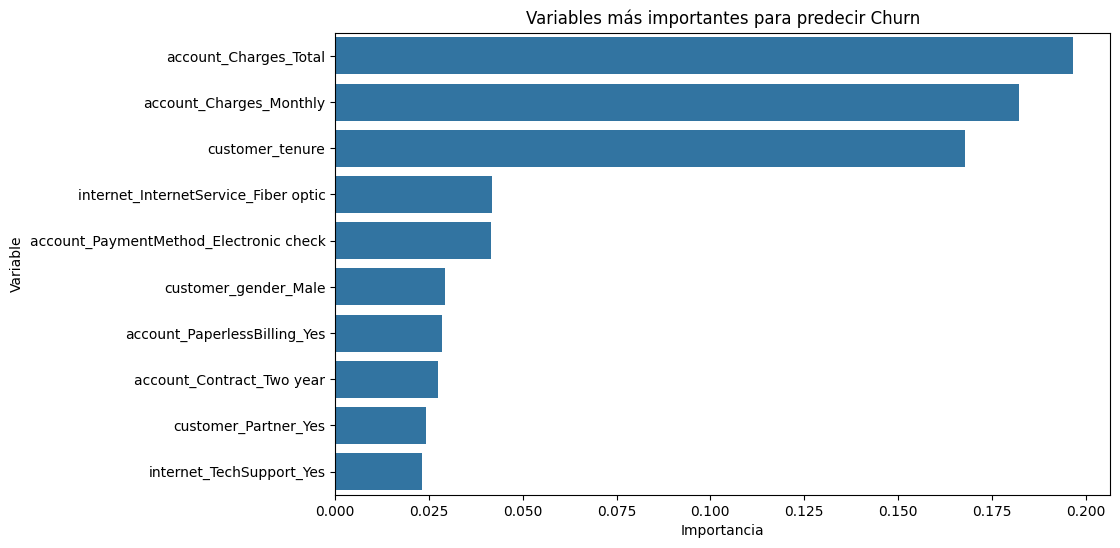

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x="Importancia", y="Variable", data=importances.head(10))

plt.title("Variables más importantes para predecir Churn")
plt.show()

Conclusión del análisis

El análisis de importancia de variables permite identificar factores clave en la cancelación de clientes.

Las variables más relevantes suelen ser:

Tiempo de permanencia (tenure)

Tipo de contrato

Costo mensual

Servicios adicionales

Estos resultados ayudan a las empresas a:

mejorar estrategias de retención de clientes

ofrecer promociones o contratos más largos

mejorar servicios de soporte

✅ En resumen, el análisis de variables importantes no solo mejora el modelo predictivo, sino que también proporciona información estratégica para reducir la cancelación de clientes.